In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor,plot_tree


In [57]:
url="https://github.com/Eng-Waheedullah-wazir/Decision_Tree_Regressor/raw/refs/heads/main/Concrete_Data.xls"
df=pd.read_excel(url)

In [58]:
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


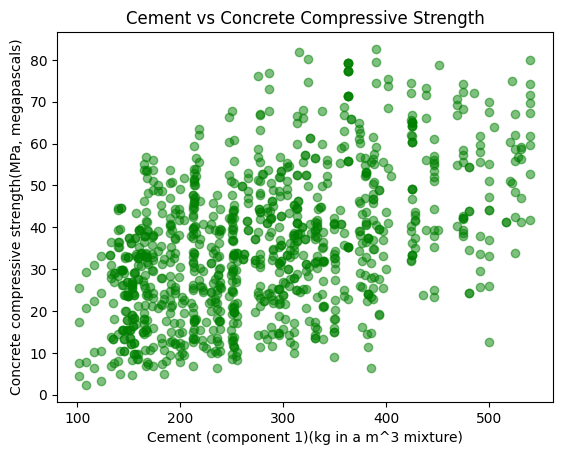

In [60]:
# Clean column names by stripping trailing/leading whitespaces
df.columns = df.columns.str.strip()

feature = df.columns.tolist()
target_col = "Concrete compressive strength(MPa, megapascals)"
feature.remove(target_col)

# Let's plot the first feature (Cement) against the target strength
x_column = "Cement (component 1)(kg in a m^3 mixture)"
plt.scatter(df[x_column], df[target_col], c="green", alpha=0.5)
plt.xlabel(x_column)
plt.ylabel(target_col)
plt.title("Cement vs Concrete Compressive Strength")
plt.show()

In [62]:
X_train,X_test,y_train,y_test=train_test_split(df[feature],df[target_col],test_size=0.2,random_state=42)

In [109]:
regressor=DecisionTreeRegressor(max_depth=20,min_samples_leaf=10)

In [110]:
regressor.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=20, min_samples_leaf=10)

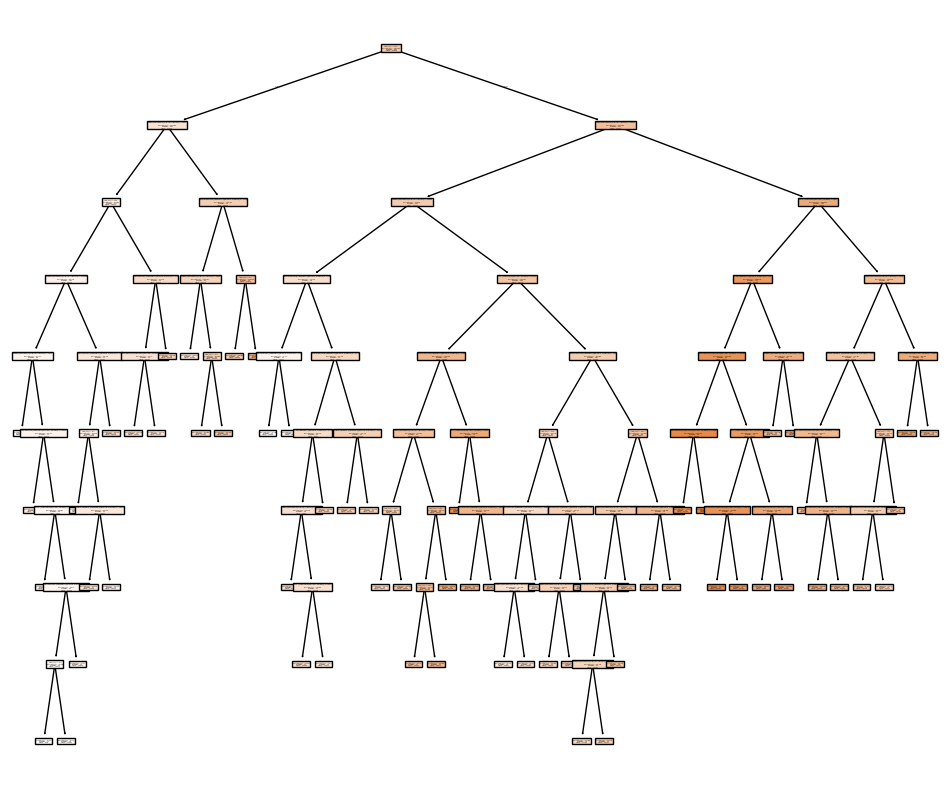

In [111]:
plt.figure(figsize=(12,10))
plot_tree(regressor, feature_names=feature, filled=True)
plt.show()

In [112]:
y_predict = regressor.predict(X_test)

In [113]:
y_predict

array([49.3894707 , 48.36918108, 74.30047393, 34.84898986, 11.60876487,
       41.52928902, 20.51211784, 50.99841826, 39.69683142, 45.36800343,
       52.83971695, 17.5280887 , 34.84898986, 28.35297681, 21.201387  ,
       17.5280887 , 50.21391655, 17.5280887 , 41.52928902, 31.62932846,
       41.52928902, 38.86162526, 45.27224775, 17.5280887 , 31.62932846,
       39.69683142, 12.30227481, 64.1883094 , 50.99841826, 13.74038536,
       64.1883094 , 45.36800343, 43.83118683, 50.99841826, 17.5280887 ,
       40.55422616, 39.69683142, 41.52928902,  7.46382394, 45.27224775,
       16.97538175,  7.46382394, 43.83118683, 56.78488048,  9.04960531,
       52.83971695, 56.78488048, 33.93732499, 25.48561849,  7.46382394,
       45.36800343, 43.83118683, 30.98633846, 17.5280887 , 57.84709908,
       34.84898986, 31.62932846, 12.30227481, 38.86162526, 20.33699624,
       41.52928902, 13.74038536, 28.52409819, 48.36918108, 32.74685961,
       30.52916265, 32.74685961, 11.60876487, 28.52409819, 24.53

In [114]:
regressor.score(X_test, y_test)

0.7542754888370072

In [115]:
regressor.score(X_train,y_train)

0.8846757236467796